In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler as mms 
from sklearn.gaussian_process import GaussianProcessRegressor as gpr
from sklearn.model_selection import train_test_split
from GA_functions import fitness, select_parents, crossover, mutation, GA_algorithm, GA_algorithm_unnormalized, conc_to_spectra, perform_iteration, set_seed #normalize_and_pca
from tree_search_functions import zeroth_iteration, nth_iteration, plot_fitness, plot_spectra, plot_DLS
from SAXS_model import model, model2
from spectroscopy import obtain_spectra

In [2]:
def perform_UV_vis(next_gen_conc, conc_array_actual, spectra_array_actual):
    #Line of code performs UV-Vis on the input parameter: next_gen_conc
    current_gen_spectra = conc_to_spectra(next_gen_conc, sample_spectra[:,1:sample_conc.shape[1]+1])
    ################################################################################################
    conc_array_actual = np.vstack((conc_array_actual, next_gen_conc))
    spectra_array_actual = np.vstack((spectra_array_actual, current_gen_spectra))
    return current_gen_spectra, conc_array_actual, spectra_array_actual

def perform_DLS(next_gen_conc, DLS_array_actual, conc_array_actual):
    distance_list = []
    for i in range(next_gen_conc.shape[0]):
        distance = 5*next_gen_conc[i,0] - 4*next_gen_conc[i,1] + 2*next_gen_conc[i,2]
        distance_list.append(distance)
    current_gen_DLS = np.asarray(distance_list).reshape(-1,1)
    DLS_array_actual = np.vstack((DLS_array_actual, current_gen_DLS))
    conc_array_actual = np.vstack((conc_array_actual, next_gen_conc))
    return current_gen_DLS, conc_array_actual, DLS_array_actual 

def perform_DLS_zero(next_gen_conc):
    target_conc = np.array([0.500, 0.014, 0.486])
    distance_list = []
    for i in range(next_gen_conc.shape[0]):
        distance = np.sum(np.abs(next_gen_conc[i] - target_conc)) + 5
        distance_list.append(distance)
    current_gen_DLS = np.asarray(distance_list).reshape(-1,1)
    return current_gen_DLS
    
def export_to_csv(conc_array):
    sample_volume = 300 #uL 
    conc_array = conc_array*sample_volume
    df = pd.DataFrame(conc_array, columns =['red-stock', 'green-stock', 'blue-stock'])
    df.to_csv("concentration_array.csv", index = False)

def import_from_excel(filename, conc_array_actual, spectra_array_actual):
    sample_spectra = pd.read_excel(filename)
    current_gen_spectra = np.asarray(sample_spectra)
    conc_array_actual = np.vstack((conc_array_actual, next_gen_conc))
    spectra_array_actual = np.vstack((spectra_array_actual, current_gen_spectra))
    return current_gen_spectra, conc_array_actual, spectra_array_actual 

def perform_simulations(conc_array, wavelength_1, wavelength_2):
    for i in range(conc_array.shape[0]):
        spectra_1_row = model(wavelength_1, 10*conc_array[i,0], 3*conc_array[i,1]).reshape(1,-1) 
        spectra_2_row = model2(wavelength_1, 10*conc_array[i,0], 3*conc_array[i,1]).reshape(1,-1) 
        #spectra_2_row = obtain_spectra(3, 3, 0.5, wavelength_2)[:,1].reshape(1,-1)
        if i == 0:
            spectra_array_1 = spectra_1_row
            spectra_array_2 = spectra_2_row
        else:
            spectra_array_1 = np.vstack((spectra_array_1, spectra_1_row))
            spectra_array_2 = np.vstack((spectra_array_2, spectra_2_row))
    return spectra_array_1, spectra_array_2

### Initialize first iteration of Input parameters and Output parameters

In [3]:
np.random.seed(2)
conc_array = np.random.dirichlet((1, 1), 30)
wavelength_1 = np.linspace(1e-1, 1, 81)
wavelength_2 = np.linspace(1e-1, 1, 81)
for i in range(conc_array.shape[0]):
    spectra_1_row = model(wavelength_1, 10*conc_array[i,0], 3*conc_array[i,1]).reshape(1,-1) 
    spectra_2_row = model(wavelength_1, 10*conc_array[i,0], 3*conc_array[i,1]).reshape(1,-1) 
    if i == 0:
        spectra_array_1 = spectra_1_row
        spectra_array_2 = spectra_2_row
    else:
        spectra_array_1 = np.vstack((spectra_array_1, spectra_1_row))
        spectra_array_2 = np.vstack((spectra_array_2, spectra_2_row))

### Initialize Targets

In [4]:
desired_spectra_1 = model(wavelength_1, 5,2).reshape(1,-1) 
desired_spectra_2 = model2(wavelength_2, 2,.5).reshape(1,-1) 

## Analyze Fitness of Zeroth Iteration

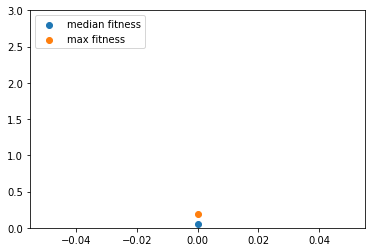

The max fitness is: 0.19389483909285998
The median fitness is: 0.055731605422942074


In [5]:
#spectra_array_1 = spectra_array_1.T
#spectra_array_1 = mms().fit(spectra_array_1).transform(spectra_array_1).T
#desired_spectra_1 = desired_spectra_1.reshape(-1,1)
#desired_spectra_1 = mms().fit(desired_spectra_1).transform(desired_spectra_1)
desired_spectra_1 = desired_spectra_1.reshape(-1,1)
#spectra_array_2 = spectra_array_2.T
#spectra_array_2 = mms().fit(spectra_array_2).transform(spectra_array_2).T
desired_spectra_2 = desired_spectra_2.reshape(-1,1)
#desired_spectra_2 = mms().fit(desired_spectra_2).transform(desired_spectra_2)
loaded_dict = zeroth_iteration(conc_array = conc_array, spectra_array_1 = spectra_array_1, desired_spectra_1 = desired_spectra_1, spectra_array_2 = spectra_array_2, desired_spectra_2 = desired_spectra_2)


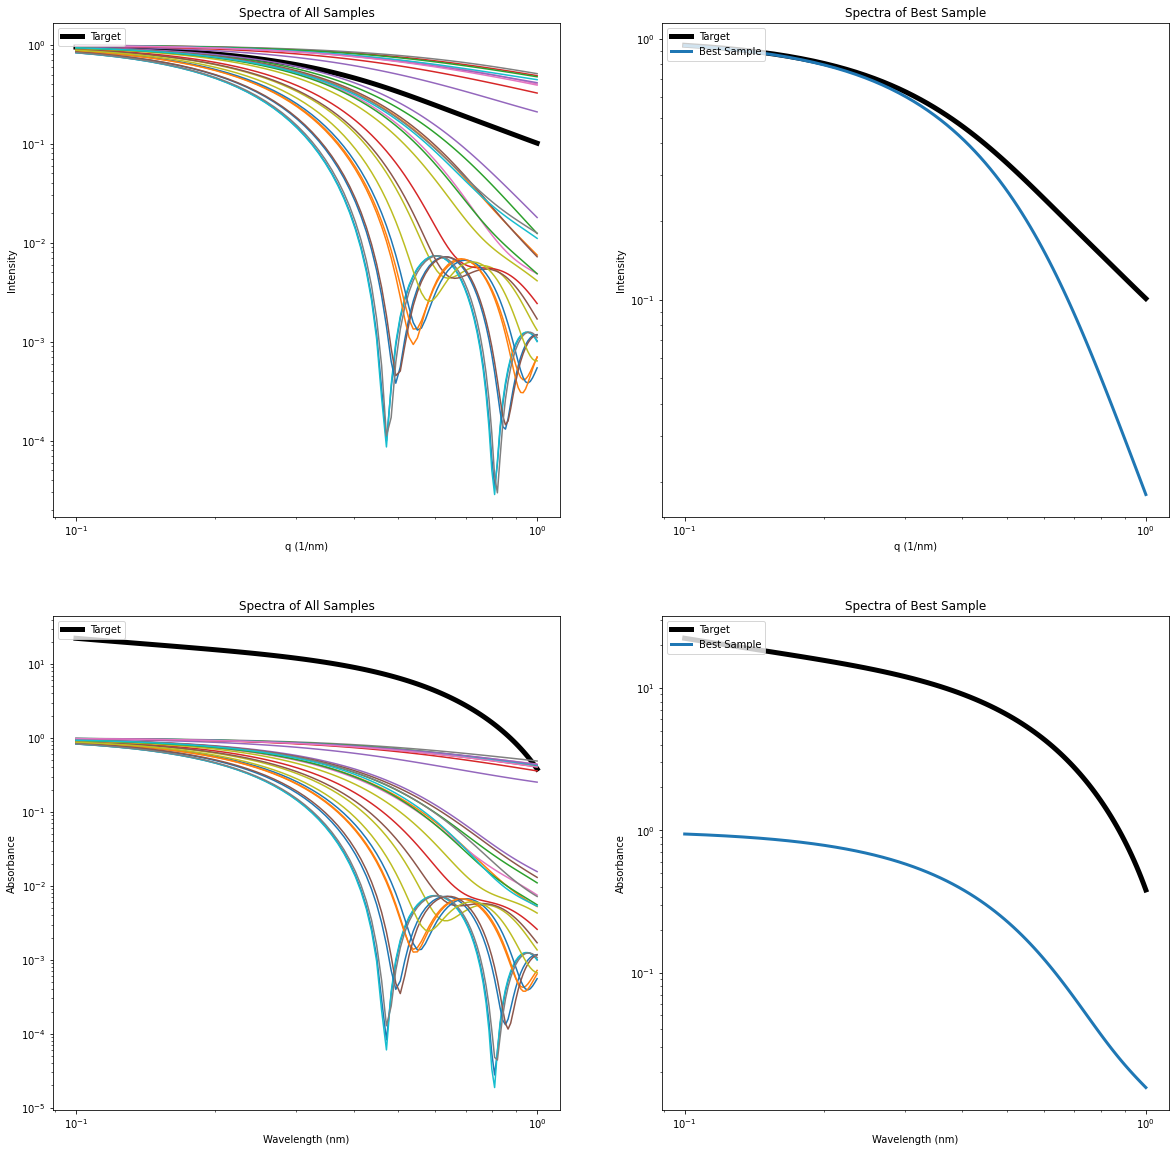

In [6]:
plot_spectra(loaded_dict, wavelength_1 = wavelength_1, wavelength_2 = wavelength_2, savefig = False)

## Nth Iteration 

In [35]:
Iterations = 25 #sample size for GA 
Moves_ahead = 3 #moves ahead that are calculated 
GA_iterations = 8 #times per move that the GA is used 
n_samples = 30 #sample size
seed = 2
###################### Setting 1 #########################################
loaded_dict = nth_iteration(loaded_dict, seed = seed, Iterations = Iterations, Moves_ahead = Moves_ahead, GA_iterations = GA_iterations, n_samples = n_samples)
###################### Setting 2 #########################################
#loaded_dict = nth_iteration(loaded_dict, seed = seed, Iterations = Iterations, Moves_ahead = Moves_ahead, GA_iterations = GA_iterations, n_samples = n_samples)


The best move has a fitness value of 4.3792279787800785
The best move occurs in 2 turns.

The surrogate model has a score of: 0.6841275006028811

[[0.44       0.4419325 ]
 [0.489      0.718     ]
 [0.491      0.742     ]
 [0.43       0.784     ]
 [0.333      0.411     ]
 [0.491      0.75071562]
 [0.48306703 0.746     ]
 [0.506      0.735     ]
 [0.42504922 0.23862447]
 [0.50843199 0.748     ]
 [0.493      0.29206124]
 [0.5        0.535     ]
 [0.594      0.551     ]
 [0.402      0.757     ]
 [0.309      0.745     ]
 [0.493      0.38515047]
 [0.429      0.213     ]
 [0.506      0.735     ]
 [0.495      0.506     ]
 [0.506      0.745     ]
 [0.58       0.541     ]
 [0.546      0.70826848]
 [0.762      0.749     ]
 [0.45543545 0.8337704 ]
 [0.187      0.735     ]
 [0.481      0.748     ]
 [0.45460465 0.73      ]
 [0.495      0.83863069]
 [0.323      0.73      ]
 [0.494      0.741     ]]


In [36]:
loaded_dict['next_gen_conc'][-1,:] = loaded_dict['best_conc_array'][:-1]
#loaded_dict['next_gen_conc'][-2,:] = loaded_dict['best_candidate_array'][-1, 0:-1]
loaded_dict['next_gen_conc'][-2,:] = np.array([0.5, 0.4])
loaded_dict['best_conc_array'][:-1]

array([0.49815047, 0.74      ])

In [37]:
spectra_array_1, spectra_array_2 = perform_simulations(loaded_dict['next_gen_conc'], wavelength_1, wavelength_2)
loaded_dict['conc_array_actual'] = np.vstack((loaded_dict['conc_array_actual'],loaded_dict['next_gen_conc']))
loaded_dict['spectra_array_actual_1'] = np.vstack((loaded_dict['spectra_array_actual_1'], spectra_array_1))
loaded_dict['spectra_array_actual_2'] = np.vstack((loaded_dict['spectra_array_actual_2'], spectra_array_2))
loaded_dict['spectra_array_1'] = spectra_array_1
loaded_dict['spectra_array_2'] = spectra_array_2
#current_gen_spectra = current_gen_spectra.T
#current_gen_spectra = mms().fit(current_gen_spectra).transform(current_gen_spectra).T
#spectra_array_actual = spectra_array_actual.T
#spectra_array_actual = mms().fit(spectra_array_actual).transform(spectra_array_actual).T
#loaded_dict['current_gen_spectra'] = current_gen_spectra

The max fitness is: 3.0818787157257557
The median fitness is: 0.2984859321389906
The best candidate has input parameters of [0.495 0.742]
The best candidate has a fitness value of 3.9270908052907565


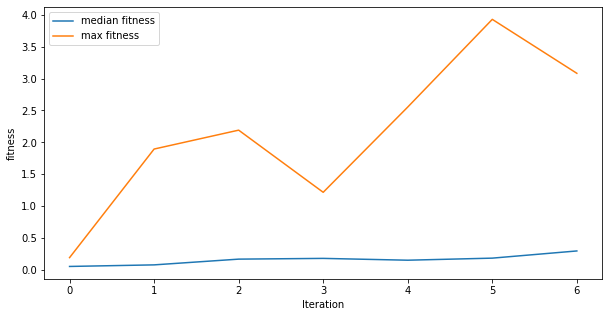

In [38]:
################## Setting 1  #################################
median_fitness_list, max_fitness_list, iteration, best_candidate_array = plot_fitness(loaded_dict, savefig = False)
loaded_dict['best_candidate_array'] = best_candidate_array
loaded_dict['median_fitness_list'] = median_fitness_list
loaded_dict['max_fitness_list'] = max_fitness_list


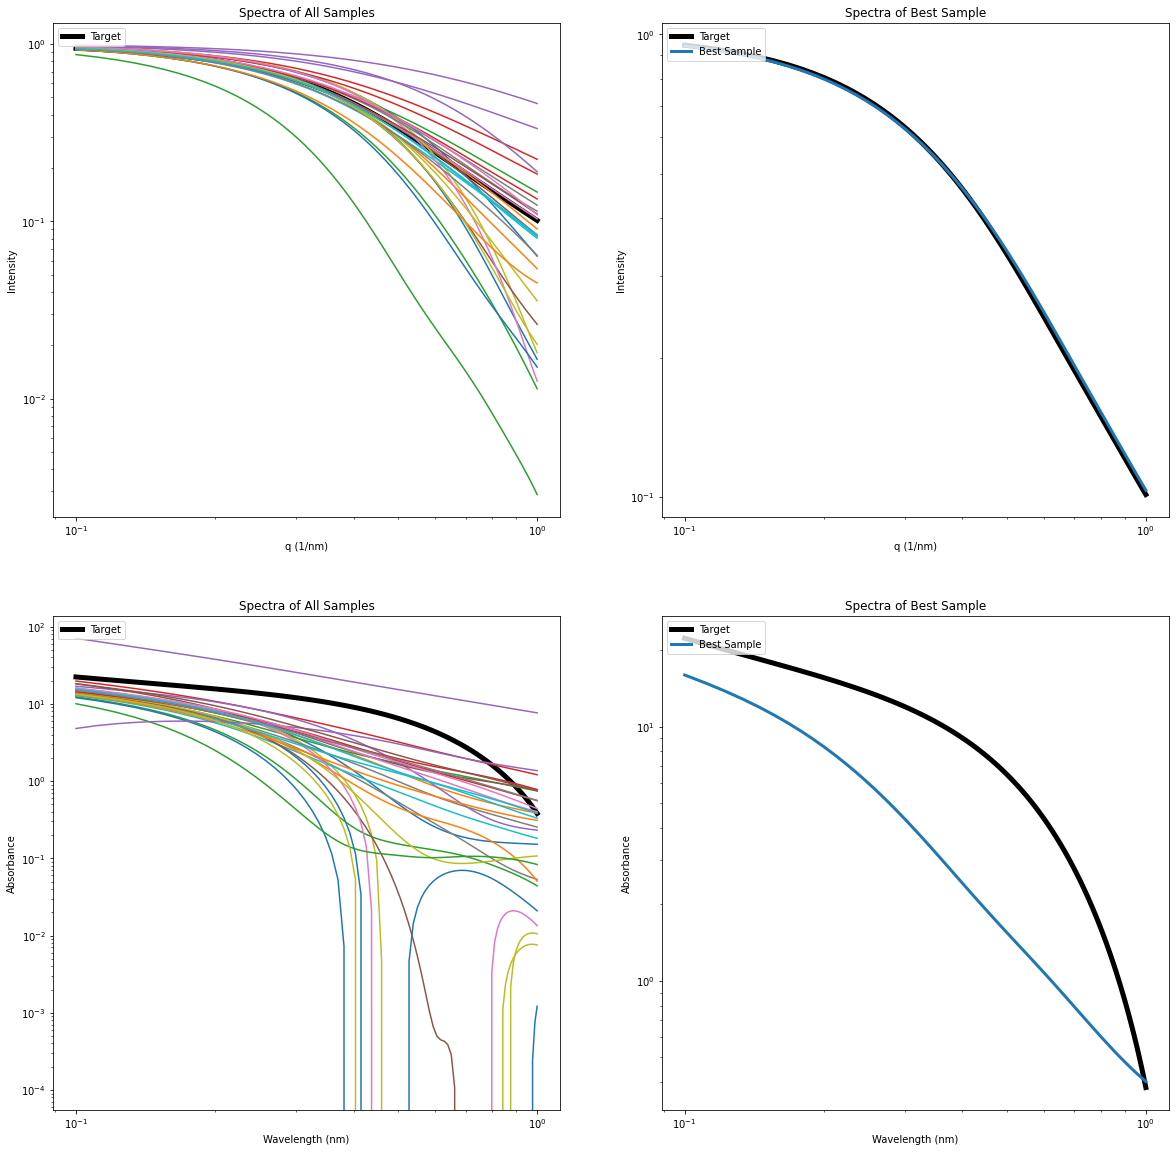

In [39]:
plot_spectra(loaded_dict, wavelength_1 = wavelength_1, wavelength_2 = wavelength_2, savefig = False)

In [40]:
loaded_dict['best_conc_array']

array([0.49815047, 0.74      , 4.41563092])